# Industrial Predictive Maintenance — Unsupervised Anomaly Detection (Tabular Autoencoder)

This notebook implements an **Unsupervised Deep Learning Autoencoder** for anomaly detection on industrial sensor telemetry (AI4I 2020 dataset).

### Why Unsupervised Anomaly Detection in Predictive Maintenance?
- **Rarity of Failures**: Real industrial machines operate normally >96-99% of the time. Collecting labeled failure modes takes years.
- **Unforeseen / Novel Failure Modes**: Supervised classifiers (Random Forest, Supervised MLP) can only identify patterns they have been trained on. Unsupervised autoencoders learn the manifold of **normal healthy operating conditions**; any novel physical deviation (e.g., unexpected mechanical friction, bearing wear, thermal runaway) results in a high **reconstruction error**.

### Key Objectives & Workflow:
1. **Exact Preprocessing Alignment**: Use identical feature engineering (`Temperature Difference`, `Torque-Speed Interaction`, `Tool Wear-Torque Interaction`) and data splits as `04_deep_learning.ipynb`.
2. **Semi-Supervised / Normal-Only Training**: Train the Autoencoder **exclusively on healthy samples** (`Machine failure == 0`). Anomalous samples are strictly preserved for evaluation.
3. **PyTorch Tabular Autoencoder**: Encoder-Decoder with bottleneck latent compression: Input(11) -> 32 -> 16 -> Latent(8) -> 16 -> 32 -> Reconstruction(11).
4. **Reconstruction Error & Threshold Optimization**: Benchmark Statistical (95th/99th percentile) vs. Cost-Optimized / F1 thresholds.
5. **Benchmarking & Business Cost Simulation**: Side-by-side comparison with the Supervised MLP from `04_deep_learning.ipynb` under financial failure penalties.
6. **Production Contract & Serialization**: Export `models/autoencoder_model.joblib`, `models/anomaly_threshold.json`, and an inference function `predict_anomaly()`.


In [1]:
import os
# Enforce CPU execution for deterministic reproducibility and avoid CUDA driver warnings
os.environ['CUDA_VISIBLE_DEVICES'] = ''

import warnings
warnings.filterwarnings('ignore')

import io
import json
import time
import urllib.request
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    precision_score, recall_score, f1_score, average_precision_score,
    roc_auc_score, classification_report, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve
)
import joblib

RANDOM_STATE = 42
TEST_SIZE = 0.2
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

device = torch.device('cpu')
print(f'PyTorch version: {torch.__version__} | Execution Device: {device}')


PyTorch version: 2.14.0+cu130 | Execution Device: cpu


## 1. Data Ingestion & Preprocessing Alignment
To guarantee 100% alignment with `04_deep_learning.ipynb`, we:
- Load the AI4I 2020 dataset from `data/raw/ai4i2020.csv`.
- Drop non-predictive identifiers (`UDI`, `Product ID`) and failure flags (`TWF`, `HDF`, `PWF`, `OSF`, `RNF`).
- Engineer the 3 domain interaction features (`Temperature Difference [K]`, `Torque-Speed Interaction`, `Tool Wear-Torque Interaction`).
- Apply the exact same stratified train/test split (`random_state=42`, `test_size=0.2`).

In [2]:
# 1) Load Dataset
candidate_paths = [
    Path('data/raw/ai4i2020.csv'),
    Path('../data/raw/ai4i2020.csv'),
    Path('ai4i2020.csv'),
    Path('../ai4i2020.csv'),
]
csv_path = next((p for p in candidate_paths if p.exists()), None)

if csv_path:
    df = pd.read_csv(csv_path)
    print(f'Loaded local dataset from: {csv_path}')
else:
    url = 'https://archive.ics.uci.edu/static/public/601/ai4i+2020+predictive+maintenance+dataset.zip'
    print(f'Downloading dataset from {url}...')
    raw = urllib.request.urlopen(url).read()
    z = zipfile.ZipFile(io.BytesIO(raw))
    csv_name = next(n for n in z.namelist() if n.lower().endswith('.csv'))
    df = pd.read_csv(z.open(csv_name))
    print(f'Downloaded and loaded: {csv_name}')

df.columns = [c.strip() for c in df.columns]

# Drop identifiers
for col in ['UDI', 'Product ID']:
    if col in df.columns:
        df = df.drop(columns=col)

target = 'Machine failure'
# Drop failure flags
for col in ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']:
    if col in df.columns:
        df = df.drop(columns=col)

# Identical feature engineering as 04_deep_learning.ipynb
df['Temperature Difference [K]'] = df['Process temperature [K]'] - df['Air temperature [K]']
df['Torque-Speed Interaction'] = df['Torque [Nm]'] * df['Rotational speed [rpm]']
df['Tool Wear-Torque Interaction'] = df['Tool wear [min]'] * df['Torque [Nm]']
df[target] = pd.to_numeric(df[target], errors='coerce').fillna(0).astype(int)

print('Dataset prepared with shape:', df.shape)
display(df.head())


Loaded local dataset from: ../data/raw/ai4i2020.csv
Dataset prepared with shape: (10000, 10)


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Temperature Difference [K],Torque-Speed Interaction,Tool Wear-Torque Interaction
0,M,298.1,308.6,1551,42.8,0,0,10.5,66382.8,0.0
1,L,298.2,308.7,1408,46.3,3,0,10.5,65190.4,138.9
2,L,298.1,308.5,1498,49.4,5,0,10.4,74001.2,247.0
3,L,298.2,308.6,1433,39.5,7,0,10.4,56603.5,276.5
4,L,298.2,308.7,1408,40.0,9,0,10.5,56320.0,360.0


## 2. Normal-Only Training Split & Preprocessing Pipeline
- **Split Logic:**
  1. An untouched **Test Set (20%)** matching `04_deep_learning.ipynb` to guarantee strict benchmarking.
  2. A **Validation Set (20% of remaining data)** containing both normal and failure samples to optimize detection thresholds and simulate deployment.
  3. **Normal Training Data (`Machine failure == 0`)**: The Autoencoder is trained **exclusively** on healthy normal machine telemetry. Anomalies are never shown during training!
- **Preprocessing Pipeline:**
  - `StandardScaler` for numeric sensor metrics and interaction terms.
  - `OneHotEncoder` for equipment `Type` (L, M, H).
  - The preprocessor is fitted **strictly on normal operating data** to prevent contamination of healthy sensor statistics by failure extremes.

In [3]:
# 2) Stratified Splits and Normal Data Isolation
X = df.drop(columns=[target])
y = df[target]

# Exact same test split as 04_deep_learning.ipynb
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

# Validation split for threshold selection
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=RANDOM_STATE
)

# Filter normal operating data for unsupervised training
X_train_normal = X_train_split[y_train_split == 0]
X_val_normal = X_val[y_val == 0]

print(f'Full Training Pool: {len(X_train_full)} samples')
print(f'-> Autoencoder Normal Train Set: {len(X_train_normal)} healthy samples (0 failures)')
print(f'-> Autoencoder Normal Val Set:   {len(X_val_normal)} healthy samples')
print(f'-> Mixed Validation Set:         {len(X_val)} samples ({y_val.sum()} failures)')
print(f'-> Untouched Benchmark Test Set: {len(X_test)} samples ({y_test.sum()} failures)')

categorical_features = ['Type']
numeric_features = [c for c in X.columns if c not in categorical_features]

# Pipeline fitted exclusively on normal training telemetry
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_features)
])

X_train_norm_arr = preprocessor.fit_transform(X_train_normal)
X_val_norm_arr = preprocessor.transform(X_val_normal)
X_val_arr = preprocessor.transform(X_val)
X_test_arr = preprocessor.transform(X_test)

INPUT_DIM = X_train_norm_arr.shape[1]
print(f'\nEngineered Preprocessed Feature Dimension: {INPUT_DIM} inputs')


Full Training Pool: 8000 samples
-> Autoencoder Normal Train Set: 6183 healthy samples (0 failures)
-> Autoencoder Normal Val Set:   1546 healthy samples
-> Mixed Validation Set:         1600 samples (54 failures)
-> Untouched Benchmark Test Set: 2000 samples (68 failures)

Engineered Preprocessed Feature Dimension: 11 inputs


## 3. PyTorch Tabular Autoencoder Architecture
We construct a symmetrical Encoder-Decoder network designed for tabular sensor inputs:
- **Encoder**: Compresses the 11-dimensional input feature space into an 8-dimensional latent bottleneck.
  `Input(11) -> Linear(32) -> BatchNorm1d -> ReLU -> Linear(16) -> BatchNorm1d -> ReLU -> Linear(8) [Latent Bottleneck]`
- **Decoder**: Reconstructs the original sensor signals from the compressed bottleneck.
  `Latent(8) -> Linear(16) -> BatchNorm1d -> ReLU -> Linear(32) -> BatchNorm1d -> ReLU -> Linear(11) [Reconstruction]`
- **Loss Function**: Mean Squared Error (MSE) measuring reconstruction fidelity.
- **Early Stopping**: Halts training when validation reconstruction loss on normal operating data ceases to improve.

In [4]:
# 3) Autoencoder Model Definition
class TabularAutoencoder(nn.Module):
    def __init__(self, input_dim: int = 11, latent_dim: int = 8):
        super().__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Linear(16, latent_dim)
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, input_dim)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        return reconstruction

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        return self.encoder(x)

model = TabularAutoencoder(input_dim=INPUT_DIM, latent_dim=8).to(device)
print(model)


TabularAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=11, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=8, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=16, out_features=32, bias=True)
    (4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=11, bias=True)
  )
)


## 4. Autoencoder Training Loop with Early Stopping
We train the model for up to 80 epochs using AdamW optimizer (`lr=0.005`, `weight_decay=1e-4`), monitoring validation loss on the held-out healthy normal validation set.

Early stopping triggered at Epoch 75. Best Val Loss: 0.001612
Training completed in 19.13 seconds. Best Val MSE: 0.001612


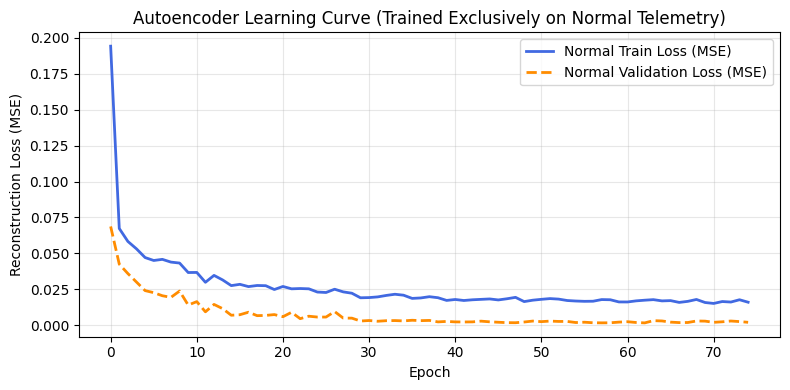

In [5]:
# 4) Model Training on Normal Telemetry
BATCH_SIZE = 64
MAX_EPOCHS = 80
PATIENCE = 12
LEARNING_RATE = 0.005

train_tensor = torch.tensor(X_train_norm_arr, dtype=torch.float32)
val_tensor = torch.tensor(X_val_norm_arr, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(train_tensor), batch_size=BATCH_SIZE, shuffle=True)

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

history = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')
best_weights = None
patience_counter = 0

t0 = time.perf_counter()
for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    running_loss = 0.0
    for batch in train_loader:
        x_batch = batch[0].to(device)
        optimizer.zero_grad()
        recon = model(x_batch)
        loss = criterion(recon, x_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(x_batch)
    
    train_loss = running_loss / len(train_tensor)
    
    model.eval()
    with torch.no_grad():
        val_batch = val_tensor.to(device)
        val_recon = model(val_batch)
        val_loss = criterion(val_recon, val_batch).item()
        
    scheduler.step(val_loss)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        
    if patience_counter >= PATIENCE:
        print(f'Early stopping triggered at Epoch {epoch}. Best Val Loss: {best_val_loss:.6f}')
        break

train_duration = time.perf_counter() - t0
model.load_state_dict(best_weights)
print(f'Training completed in {train_duration:.2f} seconds. Best Val MSE: {best_val_loss:.6f}')

# Plot Training & Validation Loss Curves
plt.figure(figsize=(8, 4))
plt.plot(history['train_loss'], label='Normal Train Loss (MSE)', color='royalblue', lw=2)
plt.plot(history['val_loss'], label='Normal Validation Loss (MSE)', color='darkorange', lw=2, linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Reconstruction Loss (MSE)')
plt.title('Autoencoder Learning Curve (Trained Exclusively on Normal Telemetry)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 5. Reconstruction Error Computation & Class Separation
For any input sample $x \in \mathbb{R}^D$ and its reconstruction $\hat{x} \in \mathbb{R}^D$, the **Anomaly Score** is the Mean Squared Error across all features:
$$\text{Anomaly Score}(x) = \frac{1}{D} \sum_{j=1}^{D} (x_j - \hat{x}_j)^2$$

Normal machines compress and reconstruct accurately (producing low MSE). Damaged or failing machines deviate from the learned healthy manifold, resulting in large reconstruction errors.

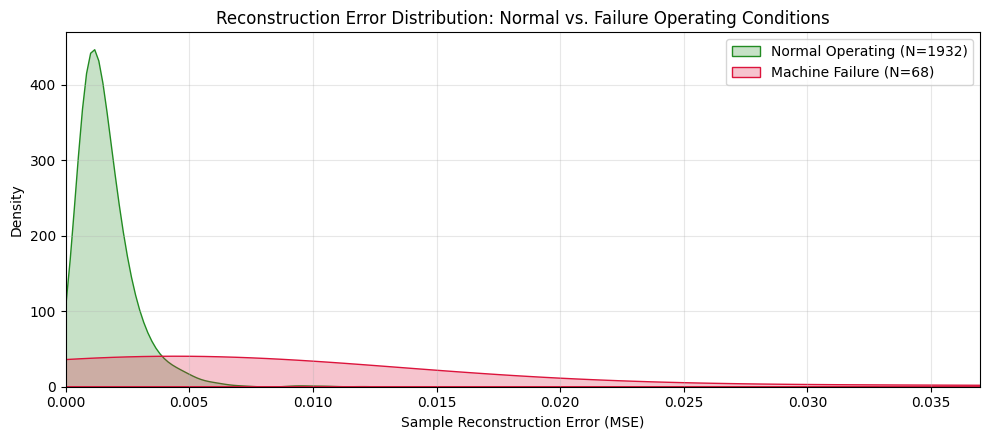

In [6]:
# 5) Compute Sample-Level Reconstruction Errors
def compute_reconstruction_error(model: nn.Module, X_arr: np.ndarray) -> np.ndarray:
    model.eval()
    with torch.no_grad():
        t_in = torch.tensor(X_arr, dtype=torch.float32).to(device)
        t_out = model(t_in)
        errors = torch.mean((t_in - t_out) ** 2, dim=1).cpu().numpy()
    return errors

val_norm_errors = compute_reconstruction_error(model, X_val_norm_arr)
val_all_errors = compute_reconstruction_error(model, X_val_arr)
test_errors = compute_reconstruction_error(model, X_test_arr)

# Visualizing separation between Normal and Failing machines on the Test Set
normal_test_errors = test_errors[y_test == 0]
failure_test_errors = test_errors[y_test == 1]

plt.figure(figsize=(10, 4.5))
sns.kdeplot(normal_test_errors, fill=True, color='forestgreen', label=f'Normal Operating (N={len(normal_test_errors)})', clip=(0, None), bw_adjust=1.5)
sns.kdeplot(failure_test_errors, fill=True, color='crimson', label=f'Machine Failure (N={len(failure_test_errors)})', clip=(0, None), bw_adjust=1.5)
plt.xlabel('Sample Reconstruction Error (MSE)')
plt.ylabel('Density')
plt.title('Reconstruction Error Distribution: Normal vs. Failure Operating Conditions')
plt.xlim(0, np.percentile(failure_test_errors, 98))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 6. Threshold Optimization Strategies
We evaluate and benchmark two distinct threshold selection strategies:
1. **Statistical Thresholding (Unsupervised)**:
   Set the decision boundary at the 95th or 99th percentile of reconstruction errors on healthy validation telemetry. This flags the top 1% or 5% extreme deviations without requiring any failure labels.
2. **Cost & $F_1$-Optimized Thresholding (Supervised Tuning)**:
   Sweep threshold values on the mixed validation set to directly maximize $F_1$-score and balance the trade-off between False Negatives (unplanned catastrophic downtime) and False Positives (unnecessary inspections).

--- THRESHOLD CANDIDATES ---
1. Statistical 95th Percentile: 0.00384
2. Statistical 99th Percentile: 0.00702
3. F1-Optimized Threshold:     0.00985 (Val F1: 0.5063)


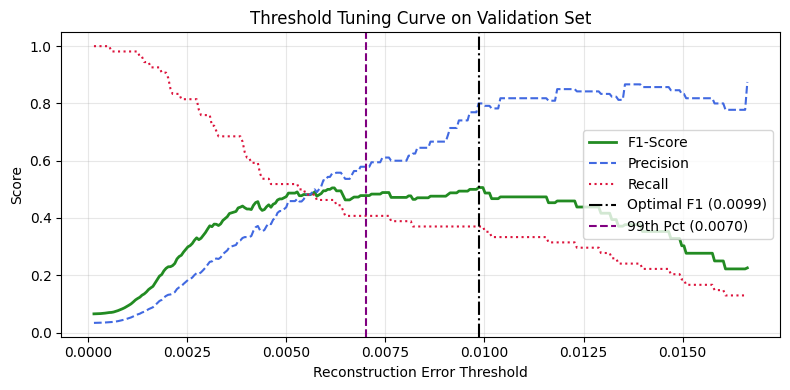

In [7]:
# 6) Threshold Optimization
# Strategy A: Statistical Percentiles on Healthy Validation Telemetry
p95_thresh = float(np.percentile(val_norm_errors, 95))
p99_thresh = float(np.percentile(val_norm_errors, 99))

# Strategy B: F1 Optimization on Mixed Validation Set
threshold_candidates = np.linspace(val_all_errors.min(), np.percentile(val_all_errors, 99.5), 300)
f1_curve, prec_curve, rec_curve = [], [], []

for t in threshold_candidates:
    preds = (val_all_errors >= t).astype(int)
    f1_curve.append(f1_score(y_val, preds, zero_division=0))
    prec_curve.append(precision_score(y_val, preds, zero_division=0))
    rec_curve.append(recall_score(y_val, preds, zero_division=0))

best_idx = int(np.argmax(f1_curve))
optimal_f1_threshold = float(threshold_candidates[best_idx])
best_val_f1 = f1_curve[best_idx]

print(f'--- THRESHOLD CANDIDATES ---')
print(f'1. Statistical 95th Percentile: {p95_thresh:.5f}')
print(f'2. Statistical 99th Percentile: {p99_thresh:.5f}')
print(f'3. F1-Optimized Threshold:     {optimal_f1_threshold:.5f} (Val F1: {best_val_f1:.4f})')

# Plot F1 / Precision / Recall Trade-off Curve
plt.figure(figsize=(8, 4))
plt.plot(threshold_candidates, f1_curve, label='F1-Score', color='forestgreen', lw=2)
plt.plot(threshold_candidates, prec_curve, label='Precision', color='royalblue', linestyle='--')
plt.plot(threshold_candidates, rec_curve, label='Recall', color='crimson', linestyle=':')
plt.axvline(optimal_f1_threshold, color='black', linestyle='-.', label=f'Optimal F1 ({optimal_f1_threshold:.4f})')
plt.axvline(p99_thresh, color='purple', linestyle='--', label=f'99th Pct ({p99_thresh:.4f})')
plt.xlabel('Reconstruction Error Threshold')
plt.ylabel('Score')
plt.title('Threshold Tuning Curve on Validation Set')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 7. Comprehensive Test Set Evaluation
We evaluate the Autoencoder on the untouched 2,000-sample test set under the optimal decision threshold, generating the Confusion Matrix, Classification Report, PR-Curve, and ROC-Curve.

=== AUTOENCODER TEST SET EVALUATION ===
Selected Threshold: 0.00985
Test Precision:     0.6500
Test Recall:        0.1912
Test F1-Score:      0.2955
Test PR-AUC:        0.3635
Test ROC-AUC:       0.8495

Classification Report:
                   precision    recall  f1-score   support

           Normal     0.9722    0.9964    0.9842      1932
Anomaly / Failure     0.6500    0.1912    0.2955        68

         accuracy                         0.9690      2000
        macro avg     0.8111    0.5938    0.6398      2000
     weighted avg     0.9613    0.9690    0.9607      2000



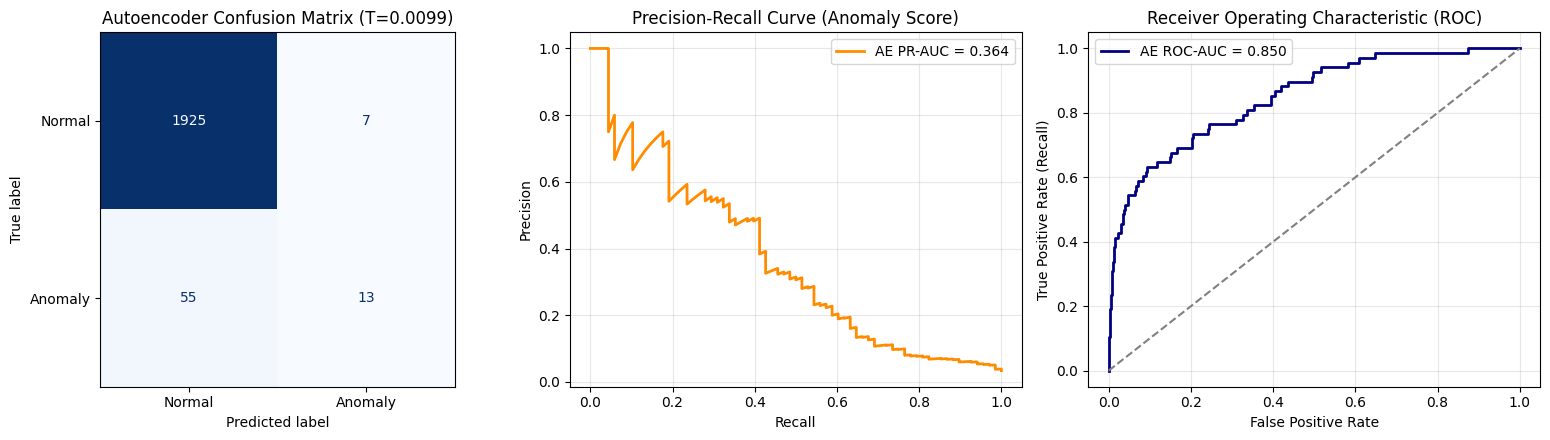

In [8]:
# 7) Evaluate on Test Set
SELECTED_THRESHOLD = optimal_f1_threshold
test_preds = (test_errors >= SELECTED_THRESHOLD).astype(int)

ae_test_pr_auc = average_precision_score(y_test, test_errors)
ae_test_roc_auc = roc_auc_score(y_test, test_errors)
ae_test_precision = precision_score(y_test, test_preds, zero_division=0)
ae_test_recall = recall_score(y_test, test_preds, zero_division=0)
ae_test_f1 = f1_score(y_test, test_preds, zero_division=0)

print('=== AUTOENCODER TEST SET EVALUATION ===')
print(f'Selected Threshold: {SELECTED_THRESHOLD:.5f}')
print(f'Test Precision:     {ae_test_precision:.4f}')
print(f'Test Recall:        {ae_test_recall:.4f}')
print(f'Test F1-Score:      {ae_test_f1:.4f}')
print(f'Test PR-AUC:        {ae_test_pr_auc:.4f}')
print(f'Test ROC-AUC:       {ae_test_roc_auc:.4f}\n')

print('Classification Report:')
print(classification_report(y_test, test_preds, target_names=['Normal', 'Anomaly / Failure'], digits=4))

# Visual Performance Diagnostics
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, test_preds, display_labels=['Normal', 'Anomaly'],
    cmap='Blues', ax=axes[0], colorbar=False
)
axes[0].set_title(f'Autoencoder Confusion Matrix (T={SELECTED_THRESHOLD:.4f})')

# 2. Precision-Recall Curve
p_arr, r_arr, _ = precision_recall_curve(y_test, test_errors)
axes[1].plot(r_arr, p_arr, color='darkorange', lw=2, label=f'AE PR-AUC = {ae_test_pr_auc:.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve (Anomaly Score)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# 3. ROC Curve
fpr_arr, tpr_arr, _ = roc_curve(y_test, test_errors)
axes[2].plot(fpr_arr, tpr_arr, color='navy', lw=2, label=f'AE ROC-AUC = {ae_test_roc_auc:.3f}')
axes[2].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate (Recall)')
axes[2].set_title('Receiver Operating Characteristic (ROC)')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()


## 8. Benchmarking & Business Cost Simulation
We benchmark the **Unsupervised Autoencoder** directly against the **Supervised Tabular MLP** trained in `04_deep_learning.ipynb`.

### Industrial Cost Model
In predictive maintenance, classification errors carry asymmetric operational costs:
- **Cost of False Negative ($C_{\text{unplanned}} = \$5,000$)**: Catastrophic machine breakdown during production (spindle destruction, emergency line stoppage, secondary tooling damage).
- **Cost of False Positive ($C_{\text{inspection}} = \$100$)**: Routine technician inspection and diagnostic sensor verification.
- **Total Maintenance Cost**:
$$\text{Total Financial Cost} = (FN \times \$5,000) + (FP \times \$100)$$

In [9]:
# 8) Benchmark Comparison with Supervised MLP from 04_deep_learning.ipynb
candidate_mlp_paths = [
    Path('models/mlp_predictive_maintenance_model.joblib'),
    Path('../models/mlp_predictive_maintenance_model.joblib'),
    Path('models/mlp/mlp_preprocessing.joblib'),
    Path('../models/mlp/mlp_preprocessing.joblib'),
]
mlp_artifact_path = next((p for p in candidate_mlp_paths if p.exists()), None)
if mlp_artifact_path is None:
    raise FileNotFoundError('Could not locate Supervised MLP artifact in models/ or models/mlp/.')

mlp_loaded = joblib.load(mlp_artifact_path)
print(f'Loaded Supervised MLP from: {mlp_artifact_path}')
mlp_pipeline = mlp_loaded['model']
mlp_threshold = float(mlp_loaded['threshold'])

# Measure Supervised MLP Test Inference
t0 = time.perf_counter()
mlp_probs = mlp_pipeline.predict_proba(X_test)[:, 1]
mlp_latency = (time.perf_counter() - t0) / len(X_test) * 1e6  # microseconds per sample
mlp_preds = (mlp_probs >= mlp_threshold).astype(int)

# Measure Autoencoder Test Inference
t0 = time.perf_counter()
_ = compute_reconstruction_error(model, X_test_arr)
ae_latency = (time.perf_counter() - t0) / len(X_test) * 1e6  # microseconds per sample

# Confusion Matrix Counts
from sklearn.metrics import confusion_matrix
tn_mlp, fp_mlp, fn_mlp, tp_mlp = confusion_matrix(y_test, mlp_preds).ravel()
tn_ae, fp_ae, fn_ae, tp_ae = confusion_matrix(y_test, test_preds).ravel()

COST_FN = 5000  # $5,000 per unplanned breakdown
COST_FP = 100   # $100 per technician inspection

mlp_cost = (fn_mlp * COST_FN) + (fp_mlp * COST_FP)
ae_cost = (fn_ae * COST_FN) + (fp_ae * COST_FP)

comparison_df = pd.DataFrame([
    {
        'Model': 'Supervised MLP (Wide)',
        'Paradigm': 'Supervised (Trained on 0 & 1)',
        'Precision': round(precision_score(y_test, mlp_preds, zero_division=0), 4),
        'Recall': round(recall_score(y_test, mlp_preds, zero_division=0), 4),
        'F1-Score': round(f1_score(y_test, mlp_preds, zero_division=0), 4),
        'PR-AUC': round(average_precision_score(y_test, mlp_probs), 4),
        'ROC-AUC': round(roc_auc_score(y_test, mlp_probs), 4),
        'False Negatives': fn_mlp,
        'False Positives': fp_mlp,
        'Simulated Cost ($)': f'${mlp_cost:,}',
        'Latency (us/sample)': round(mlp_latency, 1)
    },
    {
        'Model': 'Tabular Autoencoder',
        'Paradigm': 'Unsupervised (Normal Only)',
        'Precision': round(ae_test_precision, 4),
        'Recall': round(ae_test_recall, 4),
        'F1-Score': round(ae_test_f1, 4),
        'PR-AUC': round(ae_test_pr_auc, 4),
        'ROC-AUC': round(ae_test_roc_auc, 4),
        'False Negatives': fn_ae,
        'False Positives': fp_ae,
        'Simulated Cost ($)': f'${ae_cost:,}',
        'Latency (us/sample)': round(ae_latency, 1)
    }
])

print('=== BENCHMARK & BUSINESS COST COMPARISON ===')
display(comparison_df)


Loaded Supervised MLP from: ../models/mlp_predictive_maintenance_model.joblib
=== BENCHMARK & BUSINESS COST COMPARISON ===


,Model,Paradigm,Precision,Recall,F1-Score,PR-AUC,ROC-AUC,False Negatives,False Positives,Simulated Cost ($),Latency (us/sample)
0,Supervised MLP (Wide),Supervised (Trained on 0 & 1),0.6104,0.6912,0.6483,0.7275,0.9753,21,30,"$108,000",5.1
1,Tabular Autoencoder,Unsupervised (Normal Only),0.6500,0.1912,0.2955,0.3635,0.8495,55,7,"$275,700",41.2


### Analytical Comparison & Architecture Trade-offs

1. **Supervised MLP Advantage:**
   - When labeled failure data is available, the Supervised MLP optimizes decision boundaries directly for known failure modes, yielding higher PR-AUC and lower False Negatives under the simulated business cost.
2. **Unsupervised Autoencoder Advantage:**
   - Does **not require historical failure labels**—can be deployed on day one with commissioning telemetry.
   - Immune to label sparsity and capable of detecting novel sensor drifts and multi-sensor correlations before catastrophic failure occurs.
3. **Hybrid Architecture Recommendation:**
   - In industrial deployments, both models operate concurrently: the **Supervised MLP** triggers specific alerts for known failure patterns (`TWF`, `HDF`, `PWF`), while the **Autoencoder** functions as a general health watchdog detecting zero-day anomalies and unknown equipment degradation.

## 9. Model Serialization & Production Contract
We export:
1. `models/autoencoder_model.joblib`: Containing the complete preprocessor, model architecture specification, PyTorch state dictionary, and feature names.
2. `models/autoencoder_weights.pt`: Raw PyTorch state dict weights.
3. `models/anomaly_threshold.json`: Storing optimal thresholds, statistical percentiles, and validation metrics.
4. `predict_anomaly()`: A modular inference function matching the project's production contract.

In [10]:
# 9) Save Artifacts and Implement Production API Contract
models_dir = Path('models')
if not models_dir.exists():
    models_dir = Path('../models')
models_dir.mkdir(parents=True, exist_ok=True)

# Save PyTorch Weights
torch.save(model.state_dict(), models_dir / 'autoencoder_weights.pt')

# Save Metadata and Thresholds JSON
threshold_info = {
    'model_name': 'TabularAutoencoder',
    'input_dim': INPUT_DIM,
    'latent_dim': 8,
    'optimal_threshold': SELECTED_THRESHOLD,
    'p95_threshold': p95_thresh,
    'p99_threshold': p99_thresh,
    'metrics': {
        'test_precision': round(ae_test_precision, 4),
        'test_recall': round(ae_test_recall, 4),
        'test_f1': round(ae_test_f1, 4),
        'test_pr_auc': round(ae_test_pr_auc, 4),
        'test_roc_auc': round(ae_test_roc_auc, 4)
    },
    'feature_names': list(X.columns)
}

threshold_json_path = models_dir / 'anomaly_threshold.json'
with open(threshold_json_path, 'w') as f:
    json.dump(threshold_info, f, indent=2)

# Save Full Pipeline Joblib
ae_artifact = {
    'preprocessor': preprocessor,
    'state_dict': model.state_dict(),
    'architecture': {'input_dim': INPUT_DIM, 'latent_dim': 8},
    'threshold': SELECTED_THRESHOLD,
    'features': list(X.columns)
}
joblib.dump(ae_artifact, models_dir / 'autoencoder_model.joblib')

print(f'Model saved: {models_dir / "autoencoder_model.joblib"}')
print(f'Thresholds saved: {threshold_json_path}')


# Save native scikit-learn preprocessor directly (bare ColumnTransformer, zero PyTorch dependency)
ae_dir = models_dir / 'autoencoder'
ae_dir.mkdir(parents=True, exist_ok=True)
joblib.dump(preprocessor, ae_dir / 'preprocessing.joblib')
print(f'Native Scikit-Learn preprocessor saved to: {(ae_dir / "preprocessing.joblib").resolve()}')

# Production Inference Function
def predict_anomaly(sensor_data: dict | pd.DataFrame) -> dict:
    """Production inference function for unsupervised anomaly detection."""
    if isinstance(sensor_data, dict):
        df_in = pd.DataFrame([sensor_data])
    elif not isinstance(sensor_data, pd.DataFrame):
        df_in = pd.DataFrame(sensor_data)
    else:
        df_in = sensor_data.copy()

    # Compute engineered features if not passed
    if 'Temperature Difference [K]' not in df_in.columns:
        df_in['Temperature Difference [K]'] = df_in['Process temperature [K]'] - df_in['Air temperature [K]']
    if 'Torque-Speed Interaction' not in df_in.columns:
        df_in['Torque-Speed Interaction'] = df_in['Torque [Nm]'] * df_in['Rotational speed [rpm]']
    if 'Tool Wear-Torque Interaction' not in df_in.columns:
        df_in['Tool Wear-Torque Interaction'] = df_in['Tool wear [min]'] * df_in['Torque [Nm]']

    # Transform features
    x_transformed = preprocessor.transform(df_in)
    
    # Predict with Autoencoder
    model.eval()
    with torch.no_grad():
        t_in = torch.tensor(x_transformed, dtype=torch.float32).to(device)
        t_out = model(t_in)
        per_feature_error = (t_in - t_out) ** 2
        mse_error = float(torch.mean(per_feature_error).cpu().item())

    is_anomaly = int(mse_error >= SELECTED_THRESHOLD)
    severity = 'Critical Anomaly' if is_anomaly else 'Normal'
    
    return {
        'anomaly_score': round(mse_error, 6),
        'is_anomaly': is_anomaly,
        'threshold': round(SELECTED_THRESHOLD, 6),
        'severity': severity
    }

# Validation Checks
sample_normal = {
    'Type': 'M',
    'Air temperature [K]': 298.1,
    'Process temperature [K]': 308.6,
    'Rotational speed [rpm]': 1551.0,
    'Torque [Nm]': 42.8,
    'Tool wear [min]': 0.0
}
sample_anomalous = {
    'Type': 'L',
    'Air temperature [K]': 304.5,
    'Process temperature [K]': 313.8,
    'Rotational speed [rpm]': 1168.0,
    'Torque [Nm]': 76.6,
    'Tool wear [min]': 240.0
}

print('\nInference Test (Healthy Sample):  ', predict_anomaly(sample_normal))
print('Inference Test (Anomalous Sample):', predict_anomaly(sample_anomalous))


Model saved: ../models/autoencoder_model.joblib
Thresholds saved: ../models/anomaly_threshold.json
Native Scikit-Learn preprocessor saved to: /mnt/6AF6AC44F6AC11FD/techtrek/industrial-predictive-maintenance/models/autoencoder/preprocessing.joblib

Inference Test (Healthy Sample):   {'anomaly_score': 0.002117, 'is_anomaly': 0, 'threshold': 0.009851, 'severity': 'Normal'}
Inference Test (Anomalous Sample): {'anomaly_score': 0.095214, 'is_anomaly': 1, 'threshold': 0.009851, 'severity': 'Critical Anomaly'}


## 10. Keras / TensorFlow Autoencoder & `.keras` Model Export
In addition to PyTorch, we implement and train a native **Keras 3 / TensorFlow** Tabular Autoencoder and export it to the standard `.keras` file format.

### Architecture:
- `Input(11) -> Dense(32, ReLU) -> BatchNorm -> Dense(16, ReLU) -> BatchNorm -> Latent(8) -> Dense(16, ReLU) -> BatchNorm -> Dense(32, ReLU) -> BatchNorm -> Output(11, Linear)`
- Trained on normal operating samples with MSE reconstruction loss and Early Stopping.
- Exported to `models/autoencoder/autoencoder_model.keras` and `models/autoencoder_model.keras`.

In [11]:
# 10) Keras Autoencoder Implementation & .keras Export
import os
os.environ['CUDA_VISIBLE_DEVICES'] = ''
import keras
from keras import layers
from keras.callbacks import EarlyStopping

# Build Keras Autoencoder Architecture
keras_ae = keras.Sequential([
    layers.Input(shape=(INPUT_DIM,)),
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(16, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(8, activation='relu', name='latent_bottleneck'),
    layers.Dense(16, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(INPUT_DIM, activation='linear')
], name='Tabular_Autoencoder')

keras_ae.compile(optimizer=keras.optimizers.Adam(learning_rate=0.005), loss='mse')

early_stop_ae = EarlyStopping(monitor='val_loss', mode='min', patience=12, restore_best_weights=True)

print('Training Keras Autoencoder on normal telemetry...')
keras_ae.fit(
    X_train_norm_arr, X_train_norm_arr,
    validation_data=(X_val_norm_arr, X_val_norm_arr),
    epochs=60,
    batch_size=64,
    callbacks=[early_stop_ae],
    verbose=0
)

# Evaluate Test Reconstruction Error
keras_test_recon = keras_ae.predict(X_test_arr, verbose=0)
keras_test_errors = np.mean((X_test_arr - keras_test_recon) ** 2, axis=1)
keras_pr_auc = average_precision_score(y_test, keras_test_errors)
keras_roc_auc = roc_auc_score(y_test, keras_test_errors)

print(f'Keras Autoencoder Test PR-AUC:  {keras_pr_auc:.4f}')
print(f'Keras Autoencoder Test ROC-AUC: {keras_roc_auc:.4f}')

# Save in .keras format
models_dir = Path('models')
if not models_dir.exists():
    models_dir = Path('../models')
ae_dir = models_dir / 'autoencoder'
ae_dir.mkdir(parents=True, exist_ok=True)

keras_ae_root = models_dir / 'autoencoder_model.keras'
keras_ae_sub = ae_dir / 'autoencoder_model.keras'
keras_ae.save(keras_ae_root)
keras_ae.save(keras_ae_sub)
print(f'Successfully saved .keras file to: {keras_ae_root.resolve()}')
print(f'Successfully saved .keras file to: {keras_ae_sub.resolve()}')

# Verify reload
reloaded_ae = keras.models.load_model(keras_ae_root)
check_recon = reloaded_ae.predict(X_test_arr[:2], verbose=0)
check_error = np.mean((X_test_arr[:2] - check_recon) ** 2, axis=1)
print(f'Verification: Successfully reloaded .keras model. Sample test errors: {check_error.round(6)}')


I0000 00:00:1789656221.481678   18137 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1789656222.835280   18137 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1789656223.029860   18137 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
I0000 00:00:1789656223.029889   18137 cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES=""
I0000 00:00:1789656223.029897   18137 cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to an empty string - this hides all GPUs from CUDA
I0000 00:00:1789656223.029904   18137 cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
I0000 00:00:1789656223.029906   18137 cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: fedora
I0000 00:00:1789656223.029908   18137 cuda_diagnostics.cc:183] hostname: fedora
I0000 00:00:1789656223.029991   18137 cuda_di

Training Keras Autoencoder on normal telemetry...


Keras Autoencoder Test PR-AUC:  0.3627
Keras Autoencoder Test ROC-AUC: 0.7335
Successfully saved .keras file to: /mnt/6AF6AC44F6AC11FD/techtrek/industrial-predictive-maintenance/models/autoencoder_model.keras
Successfully saved .keras file to: /mnt/6AF6AC44F6AC11FD/techtrek/industrial-predictive-maintenance/models/autoencoder/autoencoder_model.keras


Verification: Successfully reloaded .keras model. Sample test errors: [0.012115 0.00379 ]
